In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load data

In [47]:
# Load datasets as pandas dataframes

df = pd.read_csv('data/train.csv')
X_kaggle = pd.read_csv('data/test.csv')

In [48]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [49]:
df.shape

(891, 12)

In [50]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [52]:
# Split the dataset into features (X) and labels (y)

y = df['Survived']
X = df.drop(columns=['Survived'])

In [53]:
X.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Preprocessing

In [54]:
# Plot countplots for categorical features to show survival distribution

def countplot(tmp_df):
    categorical_cols = tmp_df.select_dtypes(include=['object', 'category']).columns.tolist()
    num_plots = len(categorical_cols)
    fig, axes = plt.subplots(nrows=1, ncols=num_plots, figsize=(6 * num_plots, 5))

    for i, col in enumerate(categorical_cols):
        sns.countplot(x=col, hue='Survived', data=tmp_df, ax=axes[i], palette='Set2')
        axes[i].set_title(f'Survival Rate by {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')

    plt.tight_layout()
    plt.show()

In [55]:
# Plot heatmap of the correlation matrix for numeric features

def correlation_plot(tmp_df):
    plt.figure(figsize=(7, 5))
    sns.heatmap(tmp_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix')
    plt.show()

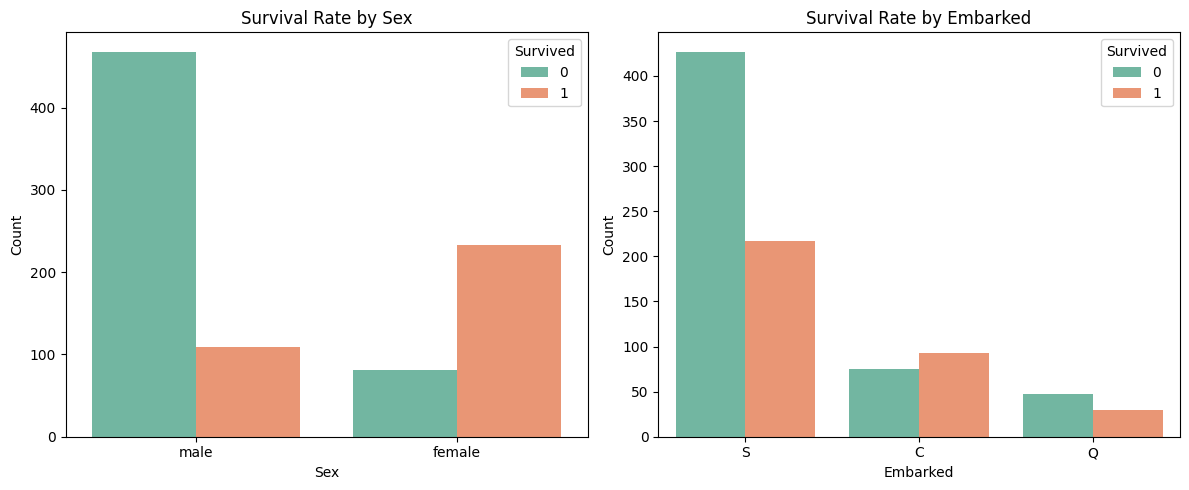

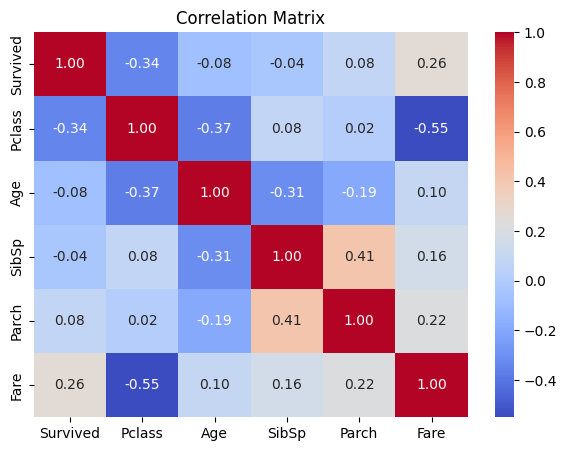

In [56]:
# Drop irrelevant columns from the dataframe 
# before plotting the countplots and the correlation matrix

tmp_df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

countplot(tmp_df)
correlation_plot(tmp_df)

In [57]:
# Delete columns that are not used or have too many nulls

X = X.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin', 'Age', 'SibSp', 'Parch', 'Embarked'])

In [58]:
X.head()

,Pclass,Sex,Fare
0,3,male,7.2500
1,1,female,71.2833
2,3,female,7.9250
3,1,female,53.1000
4,3,male,8.0500


In [62]:
X.nunique()

Pclass      3
Sex         2
Fare      248
dtype: int64

In [60]:
X.isna().sum()

Pclass    0
Sex       0
Fare      0
dtype: int64

In [63]:
# Encode categorical columns using One-Hot Encoding

X = pd.get_dummies(X, columns=['Sex'], drop_first=True, dtype=int)

In [64]:
# All columns must not contain null

X.isna().sum()

Pclass      0
Fare        0
Sex_male    0
dtype: int64

In [67]:
X.nunique()

Pclass        3
Fare        248
Sex_male      2
dtype: int64

In [68]:
# Split to train and test

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [69]:
X_train.shape

(668, 3)

In [70]:
X_test.shape

(223, 3)

## Decision Tree

In [71]:
from sklearn import tree

# create and configure the decision tree classifier with controlled complexity
clftree = tree.DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=15,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

# train the classifier on the training data
clftree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",15
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

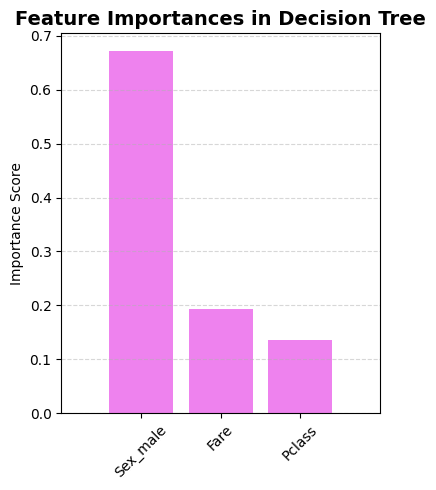

In [72]:
# Extract feature importances from the trained decision tree model
importances = clftree.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(4, 5))
plt.title("Feature Importances in Decision Tree", fontsize=14, fontweight='bold')
plt.bar(range(X.shape[1]), importances[indices], align="center", color="violet")
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=45)
plt.xlim([-1, X.shape[1]])
plt.ylabel("Importance Score")
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### Predict values using trained model

In [73]:
# Predict the output class for the training and test datasets

y_train_pred = clftree.predict(X_train)
y_test_pred = clftree.predict(X_test)

### evaluation metrics

In [74]:
# Calculate accuracy for the training set

from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score

print('On Training Set:')
print(f'Accuracy Score: {accuracy_score(y_train, y_train_pred):.3f}')

On Training Set:
Accuracy Score: 0.810


In [75]:
# Calculate all metrics for the testing set

print('On Testing Set:')
print(f'Accuracy Score: {accuracy_score(y_test, y_test_pred):.3f}')
print(f'Confusion Matrix:\n {confusion_matrix(y_test, y_test_pred)}')
print(f'Recall Score: {recall_score(y_test, y_test_pred):.3f}')
print(f'Precision Score: {precision_score(y_test, y_test_pred):.3f}')
print(f'F1 Score: {f1_score(y_test, y_test_pred):.3f}')

On Testing Set:
Accuracy Score: 0.803
Confusion Matrix:
 [[112  22]
 [ 22  67]]
Recall Score: 0.753
Precision Score: 0.753
F1 Score: 0.753


## Prepare test data for kaggle

In [76]:
# Store Passenger Ids for submission file

passenger_ids = X_kaggle['PassengerId']

In [77]:
X_kaggle.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [78]:
# Delete columns that are not used or have too many nulls

X_kaggle = X_kaggle.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin', 'Age', 'SibSp', 'Parch', 'Embarked'])

In [79]:
X_kaggle.head()

,Pclass,Sex,Fare
0,3,male,7.8292
1,3,female,7.0000
2,2,male,9.6875
3,3,male,8.6625
4,3,female,12.2875


In [80]:
# Fill in the nulls with the median

X_kaggle['Fare'] = X_kaggle['Fare'].fillna(X_kaggle['Fare'].median())

In [81]:
# Encode categorical columns using One-Hot Encoding

X_kaggle = pd.get_dummies(X_kaggle, columns=['Sex'], drop_first=True, dtype=int)

In [82]:
X_kaggle.head()

,Pclass,Fare,Sex_male
0,3,7.8292,1
1,3,7.0000,0
2,2,9.6875,1
3,3,8.6625,1
4,3,12.2875,0


In [83]:
# Predict the output class for the Kaggle test dataset

y_kaggle_pred = clftree.predict(X_kaggle)

In [84]:
# Create the submission dataframe with PassengerId and Survived columns

submission = pd.DataFrame(
    {"PassengerId": passenger_ids, "Survived": y_kaggle_pred}
)